# Fig S1 — per-read alignment error rates

Aggregates the per-read tables that `error_rates.py` writes to
`results/error-rate/error-rate-results/` into a mismatch / insertion / deletion
boxplot per dataset. Run the upstream step first (aligns against the 21
per-strain ZymoBIOMICS D6331 reference FASTAs; `--tech` is inferred per list
from its filename, so PacBio + ONT run in one command):

```bash
REF=/home/Users/pacbio_bakeoff/data/ZymoMockD6331/ZymoRef/D6331.refseq/genomes/
python scripts/read-analysis/error_rates.py --ref-dir "$REF" \
    --fastq-list data/datasets_mock_pacbio.txt data/datasets_mock_ont.txt
```

Rates are read-space: component / `(= + X + I)`, where mismatch = `X`,
insertion = `I`, deletion = `D`. A handful of over-clipped alignments give
rates > 1 — the published figure keeps them; a filtered companion drops them.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Anchor cwd to bakeoff/ regardless of where the notebook is executed from.
BAKEOFF_ROOT = next(
    (d for d in [Path.cwd(), *Path.cwd().parents]
     if (d / 'config' / 'bakeoff_env.yaml').is_file()),
    None,
)
if BAKEOFF_ROOT is None:
    raise RuntimeError(f'Could not locate bakeoff/ root from {Path.cwd()}')
os.chdir(BAKEOFF_ROOT)

ERR_DIR = Path('results/error-rate/error-rate-results')  # per_read_*.csv from error_rates.py
OUT_DIR = Path('results/error-rate')
FIG_DIR = OUT_DIR / 'figs'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Datasets drawn left to right; any extra dataset is appended after these.
DATASET_ORDER = ['SRR13128013', 'SRR13128014', 'D6331_Zymo', 'D6331_Qiagen']

# Friendlier names for the figure legend (the two PacBio mocks share an
# extraction; they differ in input mass — SRR13128013 low, SRR13128014 standard).
DATASET_LABELS = {'SRR13128013': 'low-input', 'SRR13128014': 'standard-input'}

## Load per-read tables

In [2]:
dfs = {}
for csv in sorted(ERR_DIR.glob('per_read_*.csv')):
    df = pd.read_csv(csv)
    if not df.empty:
        dfs[df['dataset'].iloc[0]] = df

if not dfs:
    raise FileNotFoundError(f'No per_read_*.csv in {ERR_DIR}; run error_rates.py first.')

datasets = [d for d in DATASET_ORDER if d in dfs] + [d for d in dfs if d not in DATASET_ORDER]
for d in datasets:
    print(f'{d}: {len(dfs[d]):,} reads')

SRR13128013: 2,770,466 reads
SRR13128014: 1,978,520 reads
D6331_Zymo: 2,962,775 reads
D6331_Qiagen: 298,133 reads


## Summary table

In [3]:
rows = []
for ds in datasets:
    df = dfs[ds]
    errors = df['errors_total'].sum()
    aligned_read = df['aligned_read'].sum()
    rows.append({
        'dataset': ds,
        'n_reads': len(df),
        'overall_error_rate_read': errors / aligned_read if aligned_read else np.nan,
        'mean_mismatch_rate_read': df['mismatch_rate_read'].mean(),
        'mean_ins_rate_read': df['ins_rate_read'].mean(),
        'mean_del_rate_read': df['del_rate_read'].mean(),
    })

summary = pd.DataFrame(rows)
summary.to_csv(OUT_DIR / 'summary_all_datasets.tsv', sep='\t', index=False)
summary

,dataset,n_reads,overall_error_rate_read,mean_mismatch_rate_read,mean_ins_rate_read,mean_del_rate_read
0,SRR13128013,2770466,0.002248,0.000148,0.000929,0.000914
1,SRR13128014,1978520,0.002187,0.000133,0.000971,0.000786
2,D6331_Zymo,2962775,0.035160,0.015407,0.007547,0.011222
3,D6331_Qiagen,298133,0.018378,0.008065,0.004116,0.005916


## Fig S1 — error components by dataset

One grouped boxplot, colored by dataset. `showfliers=True` keeps every per-read
point (including the few rates > 1 from over-clipped alignments) — the boxes
themselves sit near zero, so the visible spread is the flier cloud.

Saved: /home/Users/pacbio_bakeoff/bakeoff/results/error-rate/figs/figS1_error_components.png


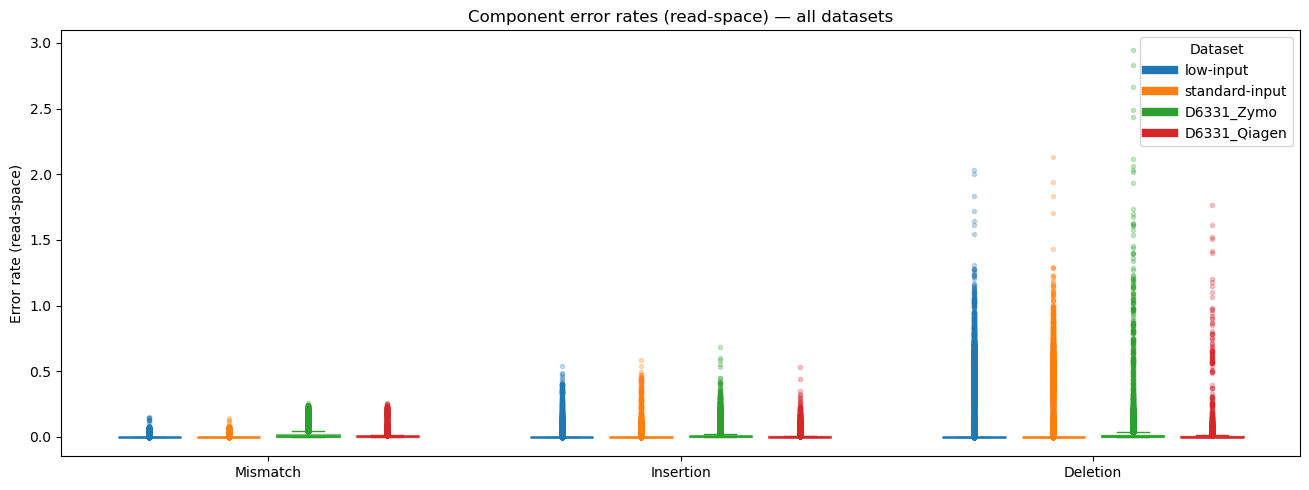

In [4]:
COMPONENTS = [('mismatch_rate_read', 'Mismatch'),
              ('ins_rate_read', 'Insertion'),
              ('del_rate_read', 'Deletion')]


def component_boxplot(frames, title, out_path, showfliers):
    """Grouped mismatch/insertion/deletion boxplot, one colored box per dataset."""
    n_ds = len(frames)
    box_gap, group_gap, width = 0.5, 0.6, 0.4
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    color = {ds: colors[i % len(colors)] for i, ds in enumerate(frames)}

    positions, data, box_ds = [], [], []
    for ci, (col, _) in enumerate(COMPONENTS):
        base = ci * (n_ds * box_gap + group_gap)
        for di, ds in enumerate(frames):
            positions.append(base + di * box_gap)
            data.append(frames[ds][col].to_numpy())
            box_ds.append(ds)
    centers = [ci * (n_ds * box_gap + group_gap) + (n_ds - 1) * box_gap / 2
               for ci in range(len(COMPONENTS))]

    fig, ax = plt.subplots(figsize=(max(8, 1.1 * len(data)), 5))
    bp = ax.boxplot(data, positions=positions, widths=width, patch_artist=True,
                    showfliers=showfliers, manage_ticks=False)
    for i, ds in enumerate(box_ds):
        c = color[ds]
        bp['boxes'][i].set(facecolor=c, edgecolor=c, alpha=0.5)
        bp['medians'][i].set(color=c, linewidth=1.8)
        for art in bp['whiskers'][2 * i:2 * i + 2] + bp['caps'][2 * i:2 * i + 2]:
            art.set(color=c)
        if showfliers:
            bp['fliers'][i].set(marker='o', markerfacecolor=c, markeredgecolor=c,
                                alpha=0.25, markersize=3)

    ax.set_xticks(centers)
    ax.set_xticklabels([label for _, label in COMPONENTS])
    ax.set_ylabel('Error rate (read-space)')
    ax.set_title(title)
    handles = [plt.Line2D([], [], color=color[ds], lw=6, label=DATASET_LABELS.get(ds, ds))
               for ds in frames]
    ax.legend(handles=handles, title='Dataset', loc='upper right')
    fig.tight_layout()
    fig.savefig(out_path, dpi=300)
    print('Saved:', out_path.resolve())


ordered = {ds: dfs[ds] for ds in datasets}
component_boxplot(ordered, 'Component error rates (read-space) — all datasets',
                  FIG_DIR / 'figS1_error_components.png', showfliers=True)

## Fig S1 (filtered, unpublished) — drop malformed alignments

Same plot with the over-clipped alignments removed (zero denominator, or any
component rate > 1), so the boxes are readable on a 0-1 scale. `showfliers=False`
keeps the focus on the box statistics.

SRR13128013: dropped 63 of 2,770,466
SRR13128014: dropped 33 of 1,978,520
D6331_Zymo: dropped 58 of 2,962,775
D6331_Qiagen: dropped 11 of 298,133
Saved: /home/Users/pacbio_bakeoff/bakeoff/results/error-rate/figs/figS1_error_components_filtered.png


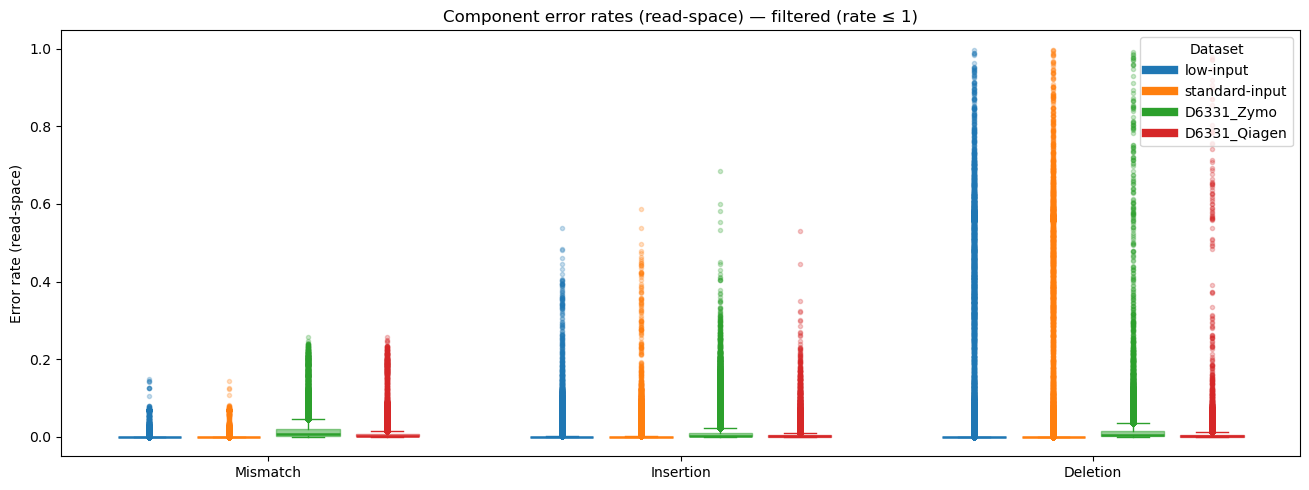

In [5]:
def drop_malformed(df):
    rate_cols = [col for col, _ in COMPONENTS]
    bad = (df['aligned_ref'] <= 0) | (df['aligned_read'] <= 0) \
        | (df[rate_cols].max(axis=1) > 1 + 1e-9)
    return df.loc[~bad]


filtered = {}
for ds in datasets:
    keep = drop_malformed(dfs[ds])
    filtered[ds] = keep
    print(f'{ds}: dropped {len(dfs[ds]) - len(keep):,} of {len(dfs[ds]):,}')

# Same plotting style as the main figure (showfliers=True); only the data differs
# (the > 1 over-clipped alignments are removed, so the flier cloud now caps near 1).
component_boxplot(filtered, 'Component error rates (read-space) — filtered (rate ≤ 1)',
                  FIG_DIR / 'figS1_error_components_filtered.png', showfliers=True)